In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r'C:\Users\shrusti\Downloads\task1_marketplace_delivery_sla_raw.csv')

In [5]:
df


,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,29-04-26,01-05-26,03-05-26,03-05-26,Bengaluru,ShipQuick,Paid,Delivered,2,1200,No
1,O1002,C02,02-05-26,03-05-26,07-05-26,07-05-26,Mumbai,shipquick,pending,delivered,3,900,No
2,O1002,C02,02-05-26,03-05-26,07-05-26,08-05-26,Mumbai,ShipQuick,Paid,Delivered,3,900,No
3,O1003,C03,04-05-26,05-05-26,06-05-26,06-05-26,Delhi,FastBee,Pending,Delivered,2,650,No
4,O1004,C04,05-05-26,06-05-26,01-06-26,01-06-26,Pune,Blue Dart,Paid,Delivered,4,2000,No
5,O1005,C05,08-05-26,09-05-26,NaN,10-05-26,Chennai,Fastbee,Paid,Cancelled,3,700,No
6,O1006,C06,10-05-26,11-05-26,14-05-26,14-05-26,Mumbai,Bluedart,Paid,Delivered,3,1500,No
7,O1006,C06,10-05-26,11-05-26,14-05-26,14-05-26,Mumbai,Bluedart,Paid,Delivered,3,1500,No
8,O1007,C07,12-05-26,13-05-26,15-05-26,15-05-26,Bangalore,ShipQuick,Paid,Delivered,2,1,Yes
9,O1008,C08,15-05-26,16-05-26,18-05-26,18-05-26,Pune,FastBee,Paid,Delivered,-2,500,No


In [6]:
df.shape

(10, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        10 non-null     object
 1   customer_id     10 non-null     object
 2   order_date      10 non-null     object
 3   shipped_at      10 non-null     object
 4   delivered_at    9 non-null      object
 5   updated_at      10 non-null     object
 6   city            10 non-null     object
 7   courier         10 non-null     object
 8   payment_status  10 non-null     object
 9   order_status    10 non-null     object
 10  promised_days   10 non-null     int64 
 11  order_value     10 non-null     int64 
 12  is_test_order   10 non-null     object
dtypes: int64(2), object(11)
memory usage: 1.1+ KB


In [8]:
date_cols = ['shipped_at','delivered_at','updated_at']

In [9]:
for col in date_cols:
  df[col] = pd.to_datetime(df[col], format='%d-%m-%y', errors='coerce')

In [10]:
df

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,29-04-26,2026-05-01,2026-05-03,2026-05-03,Bengaluru,ShipQuick,Paid,Delivered,2,1200,No
1,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-07,Mumbai,shipquick,pending,delivered,3,900,No
2,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-08,Mumbai,ShipQuick,Paid,Delivered,3,900,No
3,O1003,C03,04-05-26,2026-05-05,2026-05-06,2026-05-06,Delhi,FastBee,Pending,Delivered,2,650,No
4,O1004,C04,05-05-26,2026-05-06,2026-06-01,2026-06-01,Pune,Blue Dart,Paid,Delivered,4,2000,No
5,O1005,C05,08-05-26,2026-05-09,NaT,2026-05-10,Chennai,Fastbee,Paid,Cancelled,3,700,No
6,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,Delivered,3,1500,No
7,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,Delivered,3,1500,No
8,O1007,C07,12-05-26,2026-05-13,2026-05-15,2026-05-15,Bangalore,ShipQuick,Paid,Delivered,2,1,Yes
9,O1008,C08,15-05-26,2026-05-16,2026-05-18,2026-05-18,Pune,FastBee,Paid,Delivered,-2,500,No


In [11]:
df['order_status'] = df['order_status'].str.lower().str.strip()

In [12]:
df

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,29-04-26,2026-05-01,2026-05-03,2026-05-03,Bengaluru,ShipQuick,Paid,delivered,2,1200,No
1,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-07,Mumbai,shipquick,pending,delivered,3,900,No
2,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-08,Mumbai,ShipQuick,Paid,delivered,3,900,No
3,O1003,C03,04-05-26,2026-05-05,2026-05-06,2026-05-06,Delhi,FastBee,Pending,delivered,2,650,No
4,O1004,C04,05-05-26,2026-05-06,2026-06-01,2026-06-01,Pune,Blue Dart,Paid,delivered,4,2000,No
5,O1005,C05,08-05-26,2026-05-09,NaT,2026-05-10,Chennai,Fastbee,Paid,cancelled,3,700,No
6,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,delivered,3,1500,No
7,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,delivered,3,1500,No
8,O1007,C07,12-05-26,2026-05-13,2026-05-15,2026-05-15,Bangalore,ShipQuick,Paid,delivered,2,1,Yes
9,O1008,C08,15-05-26,2026-05-16,2026-05-18,2026-05-18,Pune,FastBee,Paid,delivered,-2,500,No


In [13]:
df['is_test_order'] = df['is_test_order'].str.lower().str.strip()

In [14]:
df

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order
0,O1001,C01,29-04-26,2026-05-01,2026-05-03,2026-05-03,Bengaluru,ShipQuick,Paid,delivered,2,1200,no
1,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-07,Mumbai,shipquick,pending,delivered,3,900,no
2,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-08,Mumbai,ShipQuick,Paid,delivered,3,900,no
3,O1003,C03,04-05-26,2026-05-05,2026-05-06,2026-05-06,Delhi,FastBee,Pending,delivered,2,650,no
4,O1004,C04,05-05-26,2026-05-06,2026-06-01,2026-06-01,Pune,Blue Dart,Paid,delivered,4,2000,no
5,O1005,C05,08-05-26,2026-05-09,NaT,2026-05-10,Chennai,Fastbee,Paid,cancelled,3,700,no
6,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,delivered,3,1500,no
7,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,delivered,3,1500,no
8,O1007,C07,12-05-26,2026-05-13,2026-05-15,2026-05-15,Bangalore,ShipQuick,Paid,delivered,2,1,yes
9,O1008,C08,15-05-26,2026-05-16,2026-05-18,2026-05-18,Pune,FastBee,Paid,delivered,-2,500,no


In [15]:
eligible = df[(df['order_status'] == 'delivered')& (df['is_test_order'] == 'no') & (df['delivered_at'].dt.month == 5) & (df['promised_days'] >= 0)].copy()

In [19]:
eligible

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order,actual_transit_days
0,O1001,C01,29-04-26,2026-05-01,2026-05-03,2026-05-03,Bengaluru,ShipQuick,Paid,delivered,2,1200,no,2
1,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-07,Mumbai,shipquick,pending,delivered,3,900,no,4
2,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-08,Mumbai,ShipQuick,Paid,delivered,3,900,no,4
3,O1003,C03,04-05-26,2026-05-05,2026-05-06,2026-05-06,Delhi,FastBee,Pending,delivered,2,650,no,1
6,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,delivered,3,1500,no,3
7,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,delivered,3,1500,no,3


In [21]:
eligible['actual_transit_days'] = (eligible['delivered_at'] - eligible['shipped_at']).dt.days

In [20]:
eligible['on_time'] =(eligible['actual_transit_days'] <= eligible['promised_days'])

In [22]:
eligible

,order_id,customer_id,order_date,shipped_at,delivered_at,updated_at,city,courier,payment_status,order_status,promised_days,order_value,is_test_order,actual_transit_days,on_time
0,O1001,C01,29-04-26,2026-05-01,2026-05-03,2026-05-03,Bengaluru,ShipQuick,Paid,delivered,2,1200,no,2,True
1,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-07,Mumbai,shipquick,pending,delivered,3,900,no,4,False
2,O1002,C02,02-05-26,2026-05-03,2026-05-07,2026-05-08,Mumbai,ShipQuick,Paid,delivered,3,900,no,4,False
3,O1003,C03,04-05-26,2026-05-05,2026-05-06,2026-05-06,Delhi,FastBee,Pending,delivered,2,650,no,1,True
6,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,delivered,3,1500,no,3,True
7,O1006,C06,10-05-26,2026-05-11,2026-05-14,2026-05-14,Mumbai,Bluedart,Paid,delivered,3,1500,no,3,True


In [23]:
summary = (eligible.groupby('courier').agg(eligible_orders =('order_id', 'count'),on_time_orders =('on_time','sum')))

In [24]:
summary['on_time_rate'] = (summary['on_time_orders'] / summary['eligible_orders'])

In [25]:
summary = summary.reset_index()

In [26]:
print(summary)

     courier  eligible_orders  on_time_orders  on_time_rate
0   Bluedart                2               2           1.0
1    FastBee                1               1           1.0
2  ShipQuick                2               1           0.5
3  shipquick                1               0           0.0


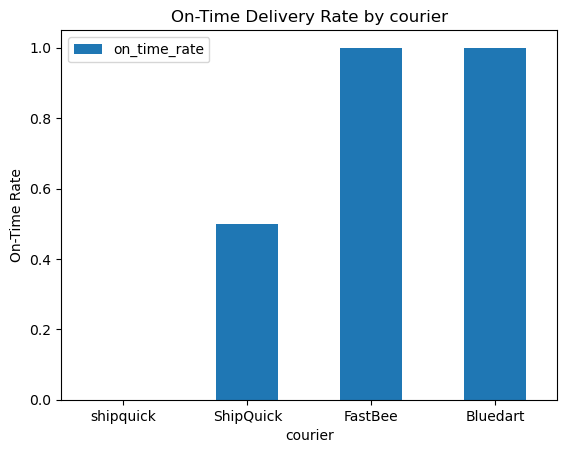

In [27]:
summary.sort_values('on_time_rate').plot(x='courier',y='on_time_rate',kind='bar')
plt.title('On-Time Delivery Rate by courier')
plt.ylabel('On-Time Rate')
plt.xticks(rotation=0)
plt.show()

NameError: name 'exclusion_reasons' is not defined

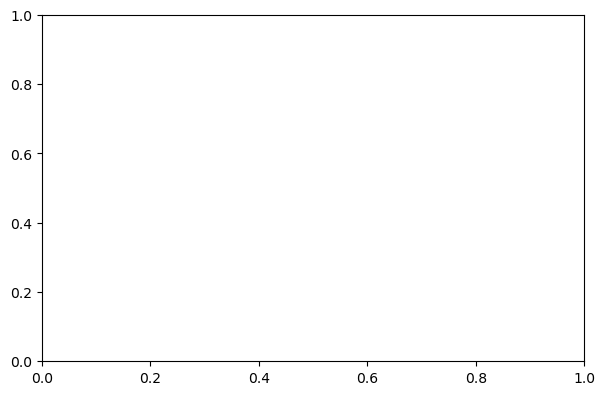

In [28]:
fig3, ax3 = plt.subplots(figsize=(7, 4.5))
ax3.barh(list(exclusion_reasons.keys()), list(exclusion_reasons.values()), color="#DD8452")
ax3.set_title("Orders Excluded from May-2026 On-Time Analysis, by Reason")
ax3.set_xlabel("Number of Orders")
plt.tight_layout()
